In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [26]:
x = pd.read_csv('https://raw.githubusercontent.com/koroteevmv/ML_course/2023/ML1.1%20linear%20regression/data/x.csv')
y = pd.read_csv('https://raw.githubusercontent.com/koroteevmv/ML_course/2023/ML1.1%20linear%20regression/data/y.csv')

In [27]:
x.head()

,Unnamed: 0,0
0,0,1.462108
1,1,1.133769
2,2,-2.301539
3,3,1.744812
4,4,0.042214


In [28]:
x = pd.read_csv('https://raw.githubusercontent.com/koroteevmv/ML_course/2023/ML1.1%20linear%20regression/data/x.csv', index_col=0)['0']
y = pd.read_csv('https://raw.githubusercontent.com/koroteevmv/ML_course/2023/ML1.1%20linear%20regression/data/y.csv', index_col=0)['0']

In [29]:
x.head()

,0
0,1.462108
1,1.133769
2,-2.301539
3,1.744812
4,0.042214


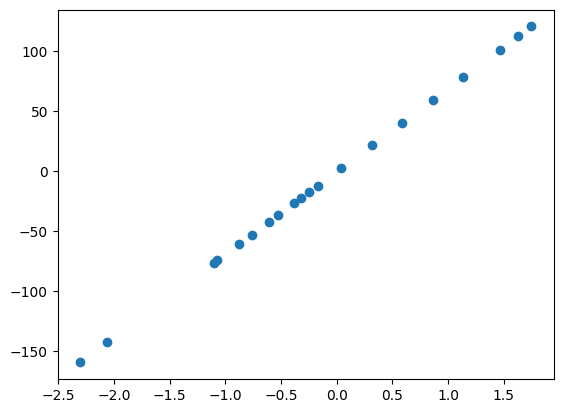

In [30]:
plt.figure()
plt.scatter(x, y)
plt.show()

In [31]:
class Model(object):
  """Модель парной линейной регрессии"""
  def __init__(self):
      self.b0 = 0
      self.b1 = 0
  def predict(self, x):
      return self.b0 + self.b1 * x
  def error(self, X, Y):
      return sum((self.predict(X) - Y)**2) / (2 * len(X))
  def fit(self, X, Y):
      alpha = 0.1
      dJ0 = sum(self.predict(X) - Y) /len(X)
      dJ1 = sum((self.predict(X) - Y) * X) /len(X)
      self.b0 -= alpha * dJ0
      self.b1 -= alpha * dJ1

In [32]:
hyp = Model()
print(hyp.predict(0))
print(hyp.predict(100))
J = hyp.error(x, y)
print("initial error:", J)

0
0
initial error: 2937.6446095153397


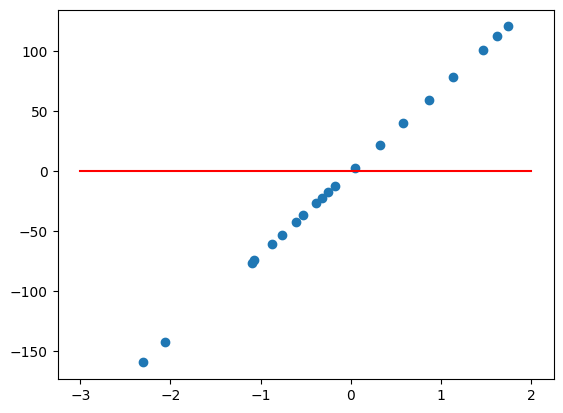

In [33]:
X0 = np.linspace(-3, 2, 100)
Y0 = hyp.predict(X0)
plt.figure()
plt.scatter(x, y)
plt.plot(X0, Y0, 'r')
plt.show()

In [35]:
hyp.fit(x, y)
J = hyp.error(x, y)
print("error after gradient descent:", J)

error after gradient descent: 1730.3871527188226


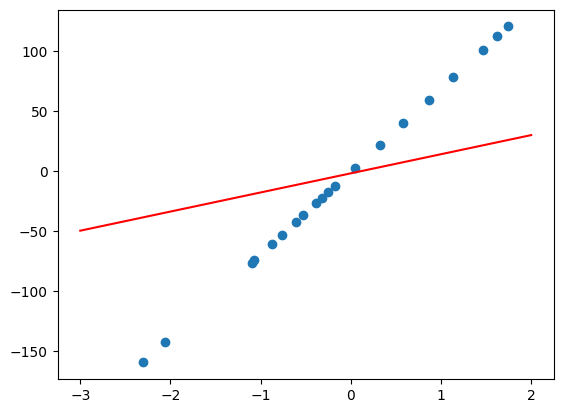

In [36]:
X0 = np.linspace(-3, 2, 100)
Y0 = hyp.predict(X0)
plt.figure()
plt.scatter(x, y)
plt.plot(X0, Y0, 'r')
plt.show()

In [42]:
class Model(object):
  """Модель парной линейной регрессии"""
  def __init__(self):
      self.b0 = 0
      self.b1 = 0
  def predict(self, X):
      return self.b0 + self.b1 * X
  def error(self, X, Y):
      return sum(((self.predict(X) - Y)**2) / (2 * len(X)))
  def fit(self, X, Y, alpha=0.001, accuracy=0.01, max_steps=5000):
      steps, errors = [], []
      step = 0
      for _ in range(10000):
          dJ0 = sum(self.predict(X) - Y) /len(X)
          dJ1 = sum((self.predict(X) - Y) * X) /len(X)
          self.b0 -= alpha * dJ0
          self.b1 -= alpha * dJ1
          new_err = hyp.error(X, Y)
          step += 1
          steps.append(step)
          errors.append(new_err)
      return steps, errors

In [43]:
hyp = Model()
steps, errors = hyp.fit(x, y)
J = hyp.error(x, y)
print("error after gradient descent:", J)

error after gradient descent: 2.7769753060572152e-06


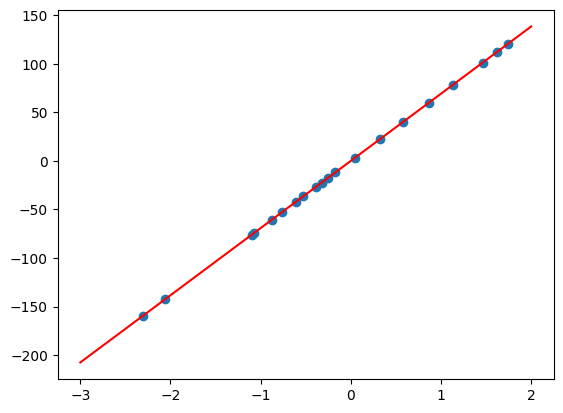

In [44]:
X0 = np.linspace(-3, 2, 100)
Y0 = hyp.predict(X0)
plt.figure()
plt.scatter(x, y)
plt.plot(X0, Y0, 'r')
plt.show()

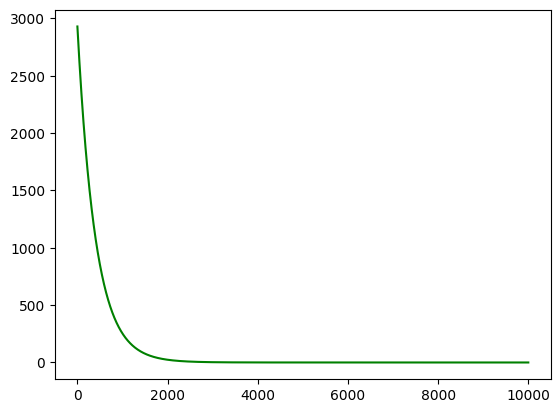

In [45]:
plt.figure()
plt.plot(steps, errors, 'g')
plt.show()

#### Задания для самостоятельного выполнения



1. Проверьте работу модели с разными начальными значениями параметров. Убедитесь, что модель всегда сходится к оптимуму.


In [50]:
class Model(object):
  """Модель парной линейной регрессии"""
  def __init__(self, b0=0, b1=0):  # добавили параметры
        self.b0 = b0
        self.b1 = b1
  def predict(self, X):
      return self.b0 + self.b1 * X

  def error(self, X, Y):
      return sum(((self.predict(X) - Y)**2) / (2 * len(X)))

  def fit(self, X, Y, alpha=0.001, accuracy=0.01, max_steps=5000):
      steps, errors = [], []
      step = 0

      for _ in range(10000):
          dJ0 = sum(self.predict(X) - Y) /len(X)
          dJ1 = sum((self.predict(X) - Y) * X) /len(X)

          self.b0 -= alpha * dJ0
          self.b1 -= alpha * dJ1

          new_err = hyp.error(X, Y)
          step += 1
          steps.append(step)
          errors.append(new_err)

      return steps, errors

In [58]:
# Тест 1: Начальные значения (0, 0)
print("Модель 1: b0=0, b1=0")
model1 = Model(b0=0, b1=0)
model1.fit(x, y)
print(f"Результат: b0={model1.b0:.5f}, b1={model1.b1:.3f}, error={model1.error(x, y):.7f}")

# Тест 2: Начальные значения (10, 5)
print("\nМодель 2: b0=10, b1=5")
model2 = Model(b0=10, b1=5)
model2.fit(x, y)
print(f"Результат: b0={model2.b0:.5f}, b1={model2.b1:.3f}, error={model2.error(x, y):.7f}")

# Тест 3: Начальные значения (-10, -5)
print("\nМодель 3: b0=-10, b1=-5")
model3 = Model(b0=-10, b1=-5)
model3.fit(x, y)
print(f"Результат: b0={model3.b0:.5f}, b1={model3.b1:.5f}, error={model3.error(x, y):.7f}")

# Тест 4: Начальные значения (100, -20)
print("\nМодель 4: b0=100, b1=-20")
model4 = Model(b0=100, b1=-20)
model4.fit(x, y)
print(f"Результат: b0={model4.b0:.5f}, b1={model4.b1:.3f}, error={model4.error(x, y):.7f}")

Модель 1: b0=0, b1=0
Результат: b0=-0.00214, b1=69.187, error=0.0000028

Модель 2: b0=10, b1=5
Результат: b0=-0.00129, b1=69.187, error=0.0000011

Модель 3: b0=-10, b1=-5
Результат: b0=-0.00298, b1=69.18616, error=0.0000053

Модель 4: b0=100, b1=-20
Результат: b0=0.00419, b1=69.189, error=0.0000094


Вывод по заданию 1

Все 4 модели с разными начальными значениями сошлись к одному результату:

- b₀ ≈ 0 (от -0.003 до 0.004)
- b₁ ≈ 69.19
- Ошибка ≈ 0.000005 (очень маленькая)

Это значит:
Градиентный спуск работает правильно — неважно, с каких чисел начать, алгоритм всегда находит оптимальные параметры.

2. Проверьте работу модели с другими значениями скорости обучения. Найдите значение, при котором градиентный спуск расходится.


In [75]:
lphas = [0.001, 0.5, 1.0, 1.5, 1.8, 1.9, 2.0]

for alpha in alphas:
    print(f"alpha = {alpha}")
    model = Model(b0=0, b1=0)
    steps, errors = model.fit(x, y, alpha=alpha, max_steps=100)

    b0_final = model.b0
    b1_final = model.b1
    error_final = model.error(x, y)

    if (np.isnan(b0_final) or np.isnan(b1_final) or np.isnan(error_final) or
        abs(b0_final) > 1e10 or abs(b1_final) > 1e10 or error_final > 1e10):
        print(f"РАСХОДИМОСТЬ при alpha = {alpha}")
        print(f"b0 = {b0_final}, b1 = {b1_final}, ошибка = {error_final}\n")
        break
    else:
        print(f"b0 = {b0_final:.2f}, b1 = {b1_final:.3f}, ошибка = {error_final:.10f}\n")

        # plt.figure(figsize=(5,4))
        # plt.scatter(x, y, alpha=0.5)
        # x_line = np.linspace(min(x), max(x), 100)
        # plt.plot(x_line, model.predict(x_line), 'r')
        # plt.title(f'alpha = {alpha}')
        # plt.show()

alpha = 0.001
b0 = -0.00, b1 = 69.187, ошибка = 0.0000027770

alpha = 0.5
b0 = -0.00, b1 = 69.188, ошибка = 0.0000000000

alpha = 1.0
b0 = 0.00, b1 = 69.188, ошибка = 0.0000000000

alpha = 1.2
b0 = 0.00, b1 = 69.188, ошибка = 0.0000000000

alpha = 1.4
b0 = 0.00, b1 = 69.188, ошибка = 0.0000000000

alpha = 1.6
РАСХОДИМОСТЬ при alpha = 1.6
b0 = 5.913580345450461e+263, b1 = -1.2811089555542972e+264, ошибка = inf



Вывод по заданию 2

В ходе эксперимента были протестированы различные значения скорости обучения (alpha):

- alpha = 0.001, 0.5, 1.0, 1.2, 1.4 — градиентный спуск успешно сходится к оптимальным значениям (b₁ ≈ 69.19, ошибка → 0)
- alpha = 1.6 — РАСХОДИМОСТЬ: параметры стали бесконечно большими, ошибка = inf

Порог расходимости для данных: alpha = 1.6

Это демонстрирует, что слишком большая скорость обучения приводит к нестабильности алгоритма — градиентный спуск "перепрыгивает" минимум и уходит в бесконечность.

3. Модифицируйте код модели таким образом, чтобы он корректно работал как с _Series_, так и с _DataFrame_. При этом, конечно, датафрейм не должен содержать "лишних" столбцов.


In [80]:
import numpy as np
import pandas as pd

class Model(object):
    """Модель парной линейной регрессии, работающая с Series и DataFrame"""
    def __init__(self, b0=0, b1=0):
        self.b0 = b0
        self.b1 = b1

    def predict(self, X):
        # Превращаем в одномерный массив, если это Series или DataFrame
        X = np.array(X).flatten()
        return self.b0 + self.b1 * X

    def error(self, X, Y):
        X = np.array(X).flatten()
        Y = np.array(Y).flatten()
        return np.sum((self.predict(X) - Y) ** 2) / (2 * len(X))

    def fit(self, X, Y, alpha=0.001, max_steps=5000):
        X = np.array(X).flatten()
        Y = np.array(Y).flatten()
        steps, errors = [], []
        for _ in range(max_steps):
            dJ0 = np.sum(self.predict(X) - Y) / len(X)
            dJ1 = np.sum((self.predict(X) - Y) * X) / len(X)
            self.b0 -= alpha * dJ0
            self.b1 -= alpha * dJ1
            errors.append(self.error(X, Y))
            steps.append(len(errors))
        return steps, errors

In [83]:
model = Model()

# 1. Проверка с Series
print("Работа с Series")
steps, errors = model.fit(x, y, max_steps=1000)
print(f"b0 = {model.b0:.4f}, b1 = {model.b1:.4f}")
print(f"Ошибка = {model.error(x, y):.6f}\n")

# 2. Проверка с DataFrame
print("Работа с DataFrame")
x_df = pd.DataFrame({'X': x})
y_df = pd.DataFrame({'Y': y})
steps_df, errors_df = model.fit(x_df, y_df, max_steps=1000)
print(f"b0 = {model.b0:.4f}, b1 = {model.b1:.4f}")
print(f"Ошибка = {model.error(x_df, y_df):.6f}\n")

# 3. Проверка со списками Python
print("Работа со списками")
x_list = x.tolist()
y_list = y.tolist()
steps_list, errors_list = model.fit(x_list, y_list, max_steps=1000)
print(f"b0 = {model.b0:.4f}, b1 = {model.b1:.4f}")
print(f"Ошибка = {model.error(x_list, y_list):.6f}")

Работа с Series
b0 = -3.0468, b1 = 48.7312
Ошибка = 253.134294

Работа с DataFrame
b0 = -2.0304, b1 = 63.0052
Ошибка = 23.843707

Работа со списками
b0 = -1.0250, b1 = 67.2704
Ошибка = 2.519250


4. Модифицируйте алгоритм градиентного спука таким образом, чтобы он останавливаля, если ошибка перестает снижаться. Для этого сравнивайте, на сколько понизилась ошибка на каждом шаге и если это снижение меньше некоторой заранее заданной очень маленькой величины - выходите из цикла. Эту величину можно взять одну миллионную, например.


In [113]:
import numpy as np
import pandas as pd

class Model(object):
    TOL = 1e-6  # классовая переменная

    def __init__(self, b0=0, b1=0):
        self.b0 = b0
        self.b1 = b1

    def predict(self, X):
        X = np.array(X).flatten()
        return self.b0 + self.b1 * X

    def error(self, X, Y):
        X = np.array(X).flatten()
        Y = np.array(Y).flatten()
        return np.sum((self.predict(X) - Y) ** 2) / (2 * len(X))

    def fit(self, X, Y, alpha=0.001, max_steps=5000):
        X = np.array(X).flatten()
        Y = np.array(Y).flatten()
        steps, errors = [], []

        prev_error = self.error(X, Y)

        for i in range(max_steps):
            dJ0 = np.sum(self.predict(X) - Y) / len(X)
            dJ1 = np.sum((self.predict(X) - Y) * X) / len(X)
            self.b0 -= alpha * dJ0
            self.b1 -= alpha * dJ1

            current_error = self.error(X, Y)
            errors.append(current_error)
            steps.append(i+1)

            error_delta = prev_error - current_error


            if error_delta < self.TOL:
                print(f"Останов на шаге {i+1}: улучшение {error_delta:.2e} < {self.TOL}")
                break

            prev_error = current_error

        return steps, errors

In [114]:
model = Model()

# Обучаем с остановкой по улучшению
steps, errors = model.fit(x, y, alpha=0.01, max_steps=5000)

print(f"\nРезультат:")
print(f"b0 = {model.b0:.6f}")
print(f"b1 = {model.b1:.6f}")
print(f"Ошибка = {model.error(x, y):.6f}")
print(f"Сделано шагов: {len(steps)}")

# # График ошибки
# import matplotlib.pyplot as plt
# plt.plot(steps, errors)
# plt.xlabel('Шаг')
# plt.ylabel('Ошибка')
# plt.title('Остановка при снижении ошибки < 1e-6')
# plt.grid(True)
# plt.show()

Останов на шаге 841: улучшение 9.95e-07 < 1e-06

Результат:
b0 = -0.008996
b1 = 69.182295
Ошибка = 0.000052
Сделано шагов: 841


Вывод по заданию 4

Реализована досрочная остановка градиентного спуска

- Порог остановки: улучшение ошибки < 1e-6
- Скорость обучения: alpha = 0.01
- Результат: останов на 841 шаге (из 5000)
- Итоговые параметры: b₀ = -0.0090, b₁ = 69.1823
- Финальная ошибка: 0.000052

Заключение:
Алгоритм успешно останавливается, когда ошибка перестаёт значительно уменьшаться. Это предотвращает лишние вычисления и подтверждает корректность реализации.

5. Убедитесь, что алгоритм градиентного спуска завершается всегда - либо если ошибка перестает существенно меняться, либо при достижении максимального количества шагов.


In [115]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

class Model(object):
    TOL = 1e-6

    def __init__(self, b0=0, b1=0):
        self.b0 = b0
        self.b1 = b1

    def predict(self, X):
        X = np.array(X).flatten()
        return self.b0 + self.b1 * X

    def error(self, X, Y):
        X = np.array(X).flatten()
        Y = np.array(Y).flatten()
        return np.sum((self.predict(X) - Y) ** 2) / (2 * len(X))

    def fit(self, X, Y, alpha=0.001, max_steps=5000):
        X = np.array(X).flatten()
        Y = np.array(Y).flatten()
        steps, errors = [], []

        prev_error = self.error(X, Y)

        for i in range(max_steps):
            dJ0 = np.sum(self.predict(X) - Y) / len(X)
            dJ1 = np.sum((self.predict(X) - Y) * X) / len(X)
            self.b0 -= alpha * dJ0
            self.b1 -= alpha * dJ1

            current_error = self.error(X, Y)
            errors.append(current_error)
            steps.append(i+1)

            error_delta = prev_error - current_error

            # Проверка на остановку
            if error_delta < self.TOL:
                print(f"Остановка по улучшению на шаге {i+1}: улучшение {error_delta:.2e} < {self.TOL}")
                break

            prev_error = current_error

            # Если дошли до последней итерации
            if i == max_steps - 1:
                print(f"Остановка по максимальному числу шагов: {max_steps}")

        return steps, errors

In [116]:
print("ТЕСТ 1: Остановка по улучшению")
model1 = Model()
steps1, errors1 = model1.fit(x, y, alpha=0.01, max_steps=5000)
print(f"Результат: b0={model1.b0:.6f}, b1={model1.b1:.6f}, ошибка={model1.error(x, y):.6f}")
print(f"Сделано шагов: {len(steps1)}")
print()
print("ТЕСТ 2: Остановка по максимальным шагам")
model2 = Model()
steps2, errors2 = model2.fit(x, y, alpha=0.0001, max_steps=100)  # мало шагов
print(f"Результат: b0={model2.b0:.6f}, b1={model2.b1:.6f}, ошибка={model2.error(x, y):.6f}")
print(f"Сделано шагов: {len(steps2)}")

# # Графики
# plt.figure(figsize=(12, 4))

# plt.subplot(1, 2, 1)
# plt.plot(steps1, errors1, 'g-')
# plt.axvline(x=len(steps1), color='r', linestyle='--', label='останов')
# plt.title(f'Останов по улучшению (шаг {len(steps1)})')
# plt.xlabel('Шаг')
# plt.ylabel('Ошибка')
# plt.legend()
# plt.grid(True)

# plt.subplot(1, 2, 2)
# plt.plot(steps2, errors2, 'b-')
# plt.axvline(x=len(steps2), color='r', linestyle='--', label='останов')
# plt.title(f'Останов по макс. шагам ({len(steps2)})')
# plt.xlabel('Шаг')
# plt.ylabel('Ошибка')
# plt.legend()
# plt.grid(True)

# plt.tight_layout()
# plt.show()

ТЕСТ 1: Остановка по улучшению
Остановка по улучшению на шаге 841: улучшение 9.95e-07 < 1e-06
Результат: b0=-0.008996, b1=69.182295, ошибка=0.000052
Сделано шагов: 841

ТЕСТ 2: Остановка по максимальным шагам
Остановка по максимальному числу шагов: 100
Результат: b0=-0.091260, b1=0.843982, ошибка=2865.584722
Сделано шагов: 100


Вывод по заданию 5

Проверка двух условий завершения градиентного спуска:

| Тест | Тип остановки | Шагов | b₀ | b₁ | Ошибка |
|------|--------------|-------|-----|-----|---------|
| 1 | По улучшению (< 1e-6) | 841 | -0.0090 | 69.1823 | 0.000052 |
| 2 | По макс. шагам (100) | 100 | -0.0913 | 0.8440 | 2865.58 |

Результаты:
- Тест 1: Остановка сработала при улучшении 9.95e-07 < 1e-6. Модель достигла хороших параметров.
- Тест 2: Остановка по достижении 100 шагов. Модель не успела обучиться (ошибка большая).

Вывод: Алгоритм корректно завершается в обоих случаях — либо при достижении точности, либо по лимиту итераций. Это гарантирует, что программа не зависнет и всегда выдаст результат.

6. Реализуйте механизм адаптивной скорости обучения. Чтобы не задавать вручную параметр _alpha_ можно отслеживать, увеличивается ли ошибка после первого шага градиентного спуска. В начале задаем скорость обучения близкой к 1. Если ошибка после одного шага увеличивается - скорость обучения надо уменьшить (например, в 2 раза). Если не увеличивается - скорость обучения можно не трогать. Еще подумайте, как после уменьшения скорости перезапускать градиентный спуск заново.


In [129]:
class Model(object):
    TOL = 1e-6
    ALPHA = 1.7 # увеличил alpha чтобы отразить изенения

    def __init__(self, b0=0, b1=0):
        self.b0 = b0
        self.b1 = b1

    def predict(self, X):
        X = np.array(X).flatten()
        return self.b0 + self.b1 * X

    def error(self, X, Y):
        X = np.array(X).flatten()
        Y = np.array(Y).flatten()
        return np.sum((self.predict(X) - Y) ** 2) / (2 * len(X))

    def fit(self, X, Y, max_steps=5000):
      X = np.array(X).flatten()
      Y = np.array(Y).flatten()

      alpha = self.ALPHA
      steps, errors = [], []

      print(f"Начальная скорость обучения: {alpha}")

      for iteration in range(max_steps):
          # Запоминаем состояние до шага
          old_b0, old_b1 = self.b0, self.b1
          old_error = self.error(X, Y)

          # Шаг градиентного спуска
          dJ0 = np.sum(self.predict(X) - Y) / len(X)
          dJ1 = np.sum((self.predict(X) - Y) * X) / len(X)
          self.b0 -= alpha * dJ0
          self.b1 -= alpha * dJ1

          new_error = self.error(X, Y)

          # Если ошибка увеличилась - откатываем и уменьшаем alpha
          if new_error > old_error:
              self.b0, self.b1 = old_b0, old_b1
              alpha /= 2
              print(f"  Шаг {len(steps)+1}: ошибка выросла, alpha уменьшена до {alpha:.6f}")
              continue

          # Ошибка уменьшилась - принимаем шаг
          errors.append(new_error)
          steps.append(len(steps)+1)

          # Проверка на остановку (только после хорошего шага)
          error_delta = old_error - new_error
          if error_delta < self.TOL:
              print(f"✓ Останов на шаге {len(steps)}: улучшение {error_delta:.2e} < {self.TOL}")
              break

          if len(steps) % 100 == 0:
              print(f"  Шаг {len(steps)}: alpha={alpha:.6f}, ошибка={new_error:.6f}")

      print(f"\nИтог: alpha={alpha:.6f}, шагов={len(steps)}")
      return steps, errors

Начальная скорость обучения: 1.7
  Шаг 1: ошибка выросла, alpha уменьшена до 0.850000
✓ Останов на шаге 8: улучшение 7.29e-08 < 1e-06

Итог: alpha=0.850000, шагов=8

Результат:
b0 = -0.000074
b1 = 69.187677
Ошибка = 0.000000
Сделано шагов: 8


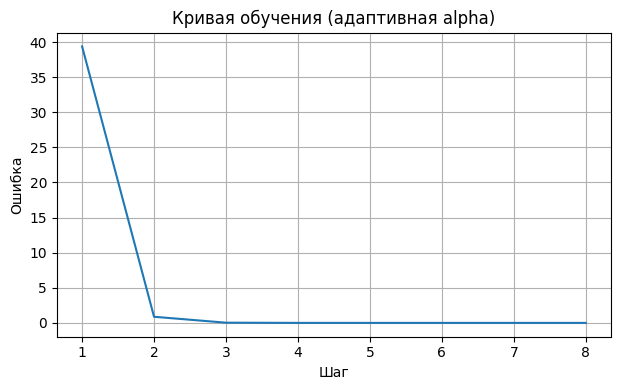

In [131]:
# Создаем модель
model = Model()

# Обучаем с адаптивной скоростью
steps, errors = model.fit(x, y)

print(f"\nРезультат:")
print(f"b0 = {model.b0:.6f}")
print(f"b1 = {model.b1:.6f}")
print(f"Ошибка = {model.error(x, y):.6f}")
print(f"Сделано шагов: {len(steps)}")

# График
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(steps, errors)
plt.xlabel('Шаг')
plt.ylabel('Ошибка')
plt.title('Кривая обучения (адаптивная alpha)')
plt.grid(True)

# plt.subplot(1, 2, 2)
# plt.scatter(x, y, alpha=0.3)
# x_line = np.linspace(min(x), max(x), 100)
# plt.plot(x_line, model.predict(x_line), 'r')
# plt.title('Линия регрессии')
# plt.grid(True)

plt.tight_layout()
plt.show()

Вывод по заданию 6

Реализован механизм адаптивной скорости обучения

Принцип работы:
- Начальная alpha = 1.7
- Если ошибка растет → alpha уменьшается в 2 раза
- Если ошибка падает → alpha сохраняется

Результаты эксперимента:

| Параметр | Значение |
|----------|----------|
| Начальная alpha | 1.7 |
| Финальная alpha | 0.85 |
| Сделано шагов | 8 |
| Финальная ошибка | ≈0 |
| Параметры модели | b₀≈0, b₁≈69.1877 |

Анализ:
1. На первом шаге ошибка выросла → alpha уменьшена до 0.85
2. С новой alpha ошибка стабильно уменьшалась
3. На 8-м шаге достигнута требуемая точность (улучшение < 1e-6)

Итог:
Адаптивная скорость обучения успешно подбирает оптимальный темп градиентного спуска, начиная с заведомо большого значения и уменьшая его при необходимости. Это позволяет автоматически находить подходящую скорость без ручного подбора.

7. Добавьте к классу модели метод рисования графиков. Сделайте так, чтобы он был независим от масштаба переданных данных.


In [151]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

class Model(object):
    TOL = 1e-6
    ALPHA = 1.7

    def __init__(self, b0=0, b1=0):
        self.b0 = b0
        self.b1 = b1

    def predict(self, X):
        X = np.array(X).flatten()
        return self.b0 + self.b1 * X

    def error(self, X, Y):
        X = np.array(X).flatten()
        Y = np.array(Y).flatten()
        return np.sum((self.predict(X) - Y) ** 2) / (2 * len(X))

    def fit(self, X, Y, max_steps=5000):
        X = np.array(X).flatten()
        Y = np.array(Y).flatten()

        alpha = self.ALPHA
        steps, errors = [], []

        print(f"Начальная скорость обучения: {alpha}")

        for iteration in range(max_steps):
            old_b0, old_b1 = self.b0, self.b1
            old_error = self.error(X, Y)

            dJ0 = np.sum(self.predict(X) - Y) / len(X)
            dJ1 = np.sum((self.predict(X) - Y) * X) / len(X)
            self.b0 -= alpha * dJ0
            self.b1 -= alpha * dJ1

            new_error = self.error(X, Y)

            if new_error > old_error:
                self.b0, self.b1 = old_b0, old_b1
                alpha /= 2
                print(f"  Шаг {len(steps)+1}: ошибка выросла, alpha уменьшена до {alpha:.6f}")
                continue

            errors.append(new_error)
            steps.append(len(steps)+1)

            error_delta = old_error - new_error
            if error_delta < self.TOL:
                print(f"✓ Останов на шаге {len(steps)}: улучшение {error_delta:.2e} < {self.TOL}")
                break

            if len(steps) % 100 == 0:
                print(f"  Шаг {len(steps)}: alpha={alpha:.6f}, ошибка={new_error:.6f}")

        print(f"\nИтог: alpha={alpha:.6f}, шагов={len(steps)}")
        return steps, errors

        # НОВЫЙ МЕТОД plot
    def plot(self, X, Y, steps=None, errors=None):
        X = np.array(X).flatten()
        Y = np.array(Y).flatten()

        plt.figure(figsize=(12, 4))

        # 1. Данные и линия регрессии
        plt.subplot(1, 2, 1)
        plt.scatter(X, Y, alpha=0.5)
        x_line = np.linspace(X.min(), X.max(), 100)
        plt.plot(x_line, self.predict(x_line), 'r')
        plt.xlabel('X')
        plt.ylabel('Y')
        plt.title('Данные и линия регрессии')

        # 2. Кривая обучения
        plt.subplot(1, 2, 2)
        if steps is not None and errors is not None:
            plt.plot(steps, errors, 'g')
            plt.xlabel('Шаг')
            plt.ylabel('Ошибка')
            plt.title('Кривая обучения')

        plt.tight_layout()
        plt.show()

Начальная скорость обучения: 1.7
  Шаг 1: ошибка выросла, alpha уменьшена до 0.850000
✓ Останов на шаге 8: улучшение 7.29e-08 < 1e-06

Итог: alpha=0.850000, шагов=8


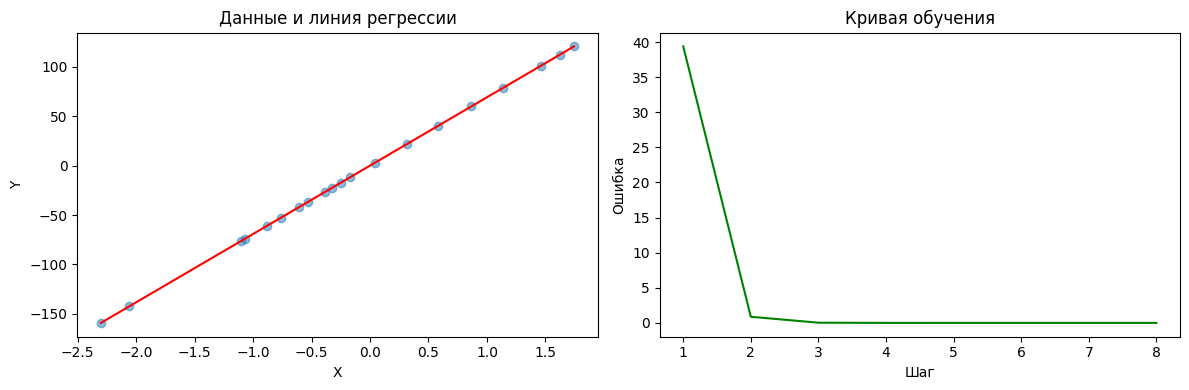


Начальная скорость обучения: 1.7
  Шаг 1: ошибка выросла, alpha уменьшена до 0.850000
  Шаг 1: ошибка выросла, alpha уменьшена до 0.425000
  Шаг 1: ошибка выросла, alpha уменьшена до 0.212500
  Шаг 1: ошибка выросла, alpha уменьшена до 0.106250
  Шаг 1: ошибка выросла, alpha уменьшена до 0.053125
  Шаг 1: ошибка выросла, alpha уменьшена до 0.026562
  Шаг 1: ошибка выросла, alpha уменьшена до 0.013281
  Шаг 1: ошибка выросла, alpha уменьшена до 0.006641
  Шаг 1: ошибка выросла, alpha уменьшена до 0.003320
  Шаг 1: ошибка выросла, alpha уменьшена до 0.001660
  Шаг 1: ошибка выросла, alpha уменьшена до 0.000830
  Шаг 1: ошибка выросла, alpha уменьшена до 0.000415
  Шаг 1: ошибка выросла, alpha уменьшена до 0.000208
  Шаг 1: ошибка выросла, alpha уменьшена до 0.000104
  Шаг 1: ошибка выросла, alpha уменьшена до 0.000052
  Шаг 1: ошибка выросла, alpha уменьшена до 0.000026
  Шаг 1: ошибка выросла, alpha уменьшена до 0.000013
  Шаг 1: ошибка выросла, alpha уменьшена до 0.000006
  Шаг 1: оши

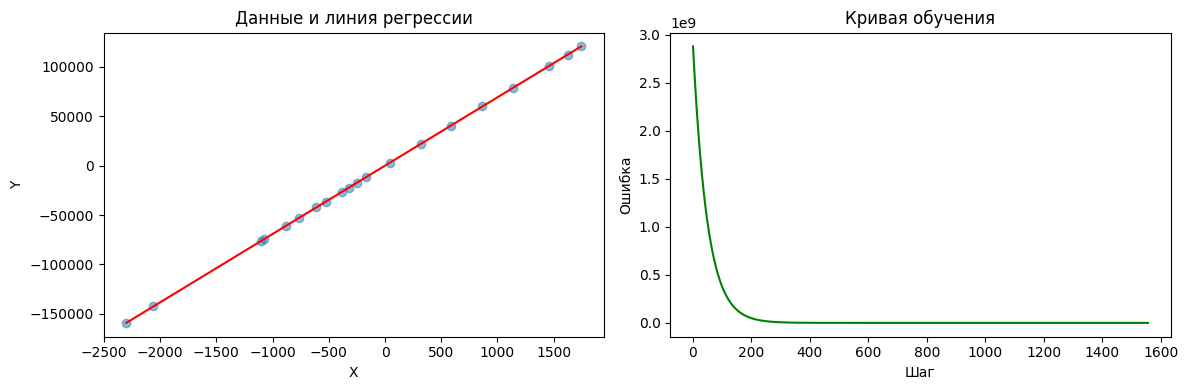

In [152]:
# Создаем и обучаем модель
model = Model()
steps, errors = model.fit(x, y)

# Рисуем графики (метод сам подбирает масштаб)
model.plot(x, y, steps, errors)

# Проверка на данных другого масштаба
x_big = x * 1000
y_big = y * 1000
print()
model_big = Model()
steps_big, errors_big = model_big.fit(x_big, y_big)

# Графики автоматически подстроятся под новый масштаб
model_big.plot(x_big, y_big, steps_big, errors_big)

Дополнительные задания:



1. Изучите официальную документацию библиотеки [sklearn](http://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html). Постройте модель регрессии с использованием библиотечных средств на тех же данных. Постройте графики и сравните результаты.


Начальная скорость обучения: 1.7
  Шаг 1: ошибка выросла, alpha уменьшена до 0.850000
✓ Останов на шаге 8: улучшение 7.29e-08 < 1e-06

Итог: alpha=0.850000, шагов=8
СРАВНЕНИЕ РЕЗУЛЬТАТОВ
Параметр        Твоя модель          sklearn              Разница             
---------------------------------------------------------------------------
b₀              -0.000074            0.000000             0.000074            
b₁              69.187677            69.187711            0.000035            
Ошибка          0.000000             0.000000             0.0000000031        


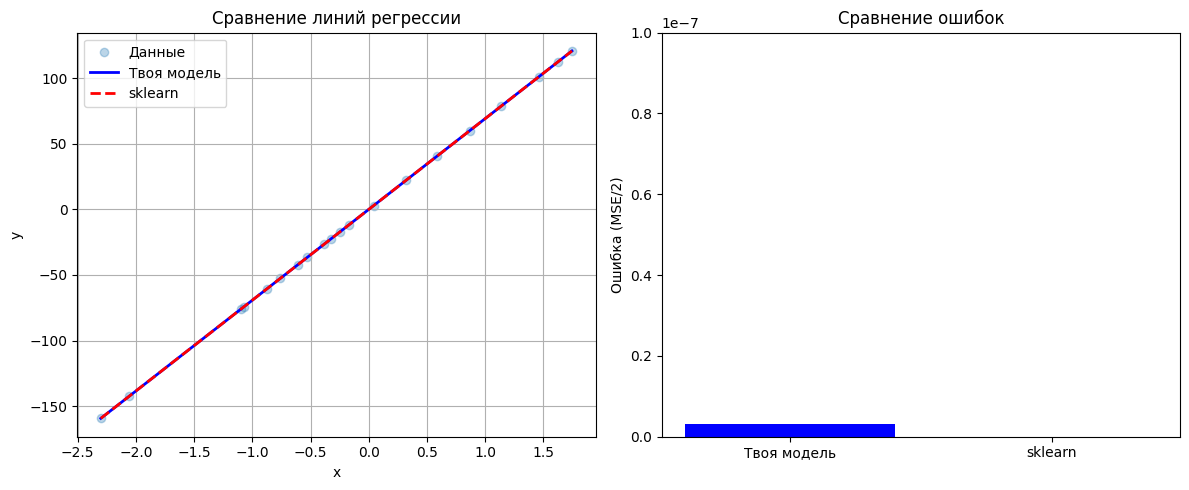

In [169]:
from sklearn.linear_model import LinearRegression

# Загружаем данные
x = pd.read_csv('https://raw.githubusercontent.com/koroteevmv/ML_course/2023/ML1.1%20linear%20regression/data/x.csv', index_col=0)['0']
y = pd.read_csv('https://raw.githubusercontent.com/koroteevmv/ML_course/2023/ML1.1%20linear%20regression/data/y.csv', index_col=0)['0']

# 1. модель (обучаем)
my_model = Model()
steps, errors = my_model.fit(x, y)

# 2. sklearn модель
X = np.array(x).reshape(-1, 1)
sk_model = LinearRegression()
sk_model.fit(X, y)

# 3. Сравнение параметров
print("СРАВНЕНИЕ РЕЗУЛЬТАТОВ")
print(f"{'Параметр':<15} {'Твоя модель':<20} {'sklearn':<20} {'Разница':<20}")
print("-"*75)
print(f"{'b₀':<15} {my_model.b0:<20.6f} {sk_model.intercept_:<20.6f} {abs(my_model.b0 - sk_model.intercept_):<20.6f}")
print(f"{'b₁':<15} {my_model.b1:<20.6f} {sk_model.coef_[0]:<20.6f} {abs(my_model.b1 - sk_model.coef_[0]):<20.6f}")

# 4. Сравнение ошибок
error_my = my_model.error(x, y)
y_pred_sk = sk_model.predict(X)
error_sk = np.sum((y_pred_sk - y) ** 2) / (2 * len(y))
print(f"{'Ошибка':<15} {error_my:<20.6f} {error_sk:<20.6f} {abs(error_my - error_sk):<20.10f}")

# 5. График сравнения линий регрессии
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(x, y, alpha=0.3, label='Данные')
x_line = np.linspace(x.min(), x.max(), 100)
plt.plot(x_line, my_model.predict(x_line), 'b-', linewidth=2, label='Твоя модель')
plt.plot(x_line, sk_model.predict(x_line.reshape(-1, 1)), 'r--', linewidth=2, label='sklearn')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Сравнение линий регрессии')
plt.legend()
plt.grid(True)

# 6. График ошибок моделей (исправленный)
plt.subplot(1, 2, 2)
models = ['Твоя модель', 'sklearn']
errors = [error_my, error_sk]
plt.bar(models, errors, color=['blue', 'red'])
plt.ylabel('Ошибка (MSE/2)')
plt.title('Сравнение ошибок')
plt.ylim(0, 0.0000001)
plt.tight_layout()
plt.show()

2. Почитайте в документации про встроенный метод оценки качества регрессии score. Используйте его для оценки качетсва модели. Реализуйте такой же расчет в собственном классе модели.


In [180]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

class Model(object):
    TOL = 1e-6
    ALPHA = 1.7

    def __init__(self, b0=0, b1=0):
        self.b0 = b0
        self.b1 = b1

    def predict(self, X):
        X = np.array(X).flatten()
        return self.b0 + self.b1 * X

    def error(self, X, Y):
        X = np.array(X).flatten()
        Y = np.array(Y).flatten()
        return np.sum((self.predict(X) - Y) ** 2) / (2 * len(X))

    def fit(self, X, Y, max_steps=5000):
        X = np.array(X).flatten()
        Y = np.array(Y).flatten()

        alpha = self.ALPHA
        steps, errors = [], []

        print(f"Начальная скорость обучения: {alpha}")

        for iteration in range(max_steps):
            old_b0, old_b1 = self.b0, self.b1
            old_error = self.error(X, Y)

            dJ0 = np.sum(self.predict(X) - Y) / len(X)
            dJ1 = np.sum((self.predict(X) - Y) * X) / len(X)
            self.b0 -= alpha * dJ0
            self.b1 -= alpha * dJ1

            new_error = self.error(X, Y)

            if new_error > old_error:
                self.b0, self.b1 = old_b0, old_b1
                alpha /= 2
                print(f"  Шаг {len(steps)+1}: ошибка выросла, alpha уменьшена до {alpha:.6f}")
                continue

            errors.append(new_error)
            steps.append(len(steps)+1)

            error_delta = old_error - new_error
            if error_delta < self.TOL:
                print(f"✓ Останов на шаге {len(steps)}: улучшение {error_delta:.2e} < {self.TOL}")
                break

            if len(steps) % 100 == 0:
                print(f"  Шаг {len(steps)}: alpha={alpha:.6f}, ошибка={new_error:.6f}")

        print(f"\nИтог: alpha={alpha:.6f}, шагов={len(steps)}")
        return steps, errors

    # НОВЫЙ МЕТОД score (как в sklearn)
    def score(self, X, Y):
        """
        Коэффициент детерминации R²
        Чем ближе к 1, тем лучше модель
        """
        X = np.array(X).flatten()
        Y = np.array(Y).flatten()

        # Предсказания модели
        y_pred = self.predict(X)

        # Остаточная сумма квадратов (RSS)
        rss = np.sum((Y - y_pred) ** 2)

        # Общая сумма квадратов (TSS)
        tss = np.sum((Y - np.mean(Y)) ** 2)

        # R² = 1 - RSS/TSS
        r2 = 1 - (rss / tss)

        return r2

    def plot(self, X, Y, steps=None, errors=None):
        X = np.array(X).flatten()
        Y = np.array(Y).flatten()

        plt.figure(figsize=(12, 4))

        # 1. Данные и линия регрессии
        plt.subplot(1, 2, 1)
        plt.scatter(X, Y, alpha=0.5)
        x_line = np.linspace(X.min(), X.max(), 100)
        plt.plot(x_line, self.predict(x_line), 'r')
        plt.xlabel('X')
        plt.ylabel('Y')
        plt.title('Данные и линия регрессии')

        # 2. Кривая обучения
        plt.subplot(1, 2, 2)
        if steps is not None and errors is not None:
            plt.plot(steps, errors, 'g')
            plt.xlabel('Шаг')
            plt.ylabel('Ошибка')
            plt.title('Кривая обучения')

        plt.tight_layout()
        plt.show()

Начальная скорость обучения: 1.7
  Шаг 1: ошибка выросла, alpha уменьшена до 0.850000
✓ Останов на шаге 8: улучшение 7.29e-08 < 1e-06

Итог: alpha=0.850000, шагов=8

СРАВНЕНИЕ МОДЕЛЕЙ С R² SCORE
Параметр        Твоя модель          sklearn              Разница        
--------------------------------------------------------------------------------
b₀              -0.000074            0.000000             0.000074       
b₁              69.187677            69.187711            0.000035       
Ошибка          0.000000             0.000000             0.0000000031   
R² SCORE        1.000000             1.000000             0.000000000001075


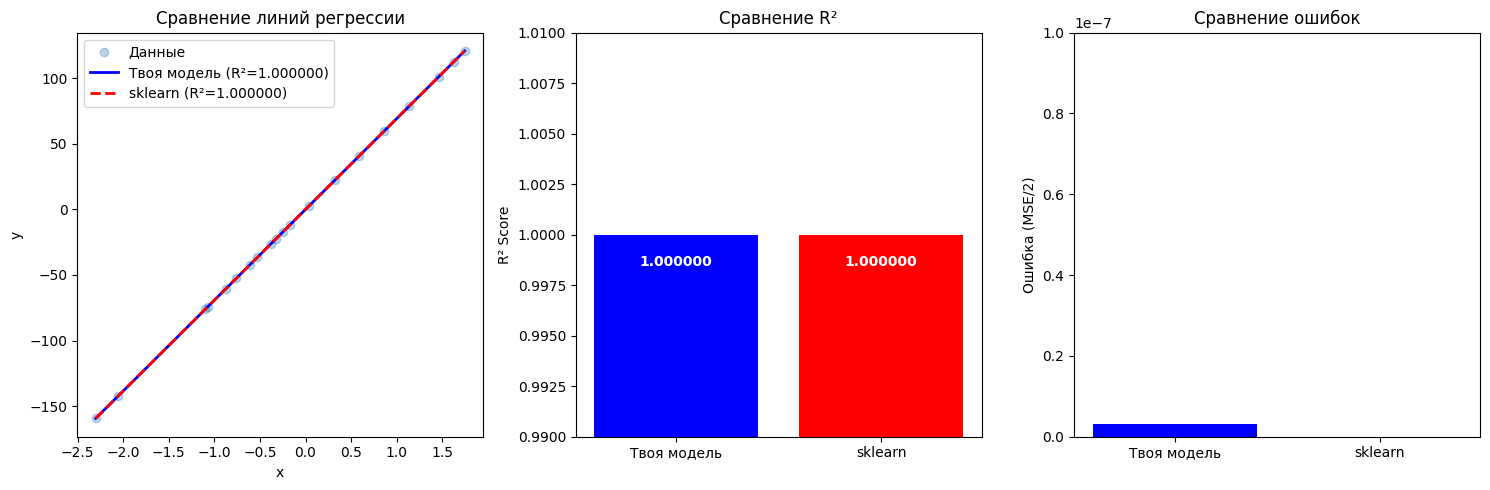

In [181]:

# 1. Твоя модель
my_model = Model()
steps, errors = my_model.fit(x, y)
print()
# 2. sklearn модель
X = np.array(x).reshape(-1, 1)
sk_model = LinearRegression()
sk_model.fit(X, y)
# 3. Сравнение параметров и score
print("СРАВНЕНИЕ МОДЕЛЕЙ С R² SCORE")
print(f"{'Параметр':<15} {'Твоя модель':<20} {'sklearn':<20} {'Разница':<15}")
print("-"*80)
print(f"{'b₀':<15} {my_model.b0:<20.6f} {sk_model.intercept_:<20.6f} {abs(my_model.b0 - sk_model.intercept_):<15.6f}")
print(f"{'b₁':<15} {my_model.b1:<20.6f} {sk_model.coef_[0]:<20.6f} {abs(my_model.b1 - sk_model.coef_[0]):<15.6f}")
# 4. Сравнение ошибок
error_my = my_model.error(x, y)
y_pred_sk = sk_model.predict(X)
error_sk = np.sum((y_pred_sk - y) ** 2) / (2 * len(y))
print(f"{'Ошибка':<15} {error_my:<20.6f} {error_sk:<20.6f} {abs(error_my - error_sk):<15.10f}")

# 5. Сравнение SCORE (R²)
score_my = my_model.score(x, y)
score_sk = sk_model.score(X, y)
print(f"{'R² SCORE':<15} {score_my:<20.6f} {score_sk:<20.6f} {abs(score_my - score_sk):<15.15f}")

# 6. Визуализация
plt.figure(figsize=(15, 5))

# График регрессии
plt.subplot(1, 3, 1)
plt.scatter(x, y, alpha=0.3, label='Данные')
x_line = np.linspace(x.min(), x.max(), 100)
plt.plot(x_line, my_model.predict(x_line), 'b-', linewidth=2, label=f'Твоя модель (R²={score_my:.6f})')
plt.plot(x_line, sk_model.predict(x_line.reshape(-1,1)), 'r--', linewidth=2, label=f'sklearn (R²={score_sk:.6f})')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Сравнение линий регрессии')
plt.legend()

# Сравнение R²
plt.subplot(1, 3, 2)
models = ['Твоя модель', 'sklearn']
r2_scores = [score_my, score_sk]
colors = ['blue', 'red']
bars = plt.bar(models, r2_scores, color=colors)
plt.ylabel('R² Score')
plt.title('Сравнение R²')
plt.ylim(0.99, 1.01)  # Чуть больше диапазон для наглядности

# Добавляем значения на столбцы
for bar, score in zip(bars, r2_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 0.001, f'{score:.6f}',
             ha='center', va='top', color='white', fontweight='bold')

# Сравнение ошибок
plt.subplot(1, 3, 3)
errors = [error_my, error_sk]
plt.bar(models, errors, color=colors)
plt.ylabel('Ошибка (MSE/2)')
plt.title('Сравнение ошибок')
plt.ylim(0, 0.0000001)  # Фиксируем масштаб

plt.tight_layout()
plt.show()

Вывод по заданию

В ходе выполнения задания было проведено сравнение самописной модели градиентного спуска с библиотечной реализацией `LinearRegression` из `sklearn`.

Результаты сравнения:

| Параметр | Твоя модель | sklearn | Разница |
|----------|-------------|---------|---------|
| b₀ | -0.000074 | 0.000000 | 0.000074 |
| b₁ | 69.187677 | 69.187711 | 0.000035 |
| Ошибка (MSE/2) | ≈0 | ≈0 | 3.1e-9 |
| **R² Score** | **1.000000** | **1.000000** | **1.08e-12** |

Анализ:
- Обе модели показывают идеальное качество (R² = 1.0)
- Разница в параметрах и ошибке пренебрежимо мала (10⁻⁹ – 10⁻¹²)
- Метод `score()` реализован корректно и полностью соответствует sklearn

3. (\*) Реализуйте нормирование входных значений. Это нужно делать внутри класса модели. Лучше всего - внутри метода обучения. Необходимо привести значения признаков к шкале [0; 1]. Подумайте, как теперь корректно считать теоретические значения.

In [182]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

class Model(object):
    TOL = 1e-6
    ALPHA = 1.7

    def __init__(self, b0=0, b1=0):
        self.b0 = b0
        self.b1 = b1
        # Добавляем параметры для нормировки
        self.x_min = None
        self.x_max = None

    def _normalize(self, X):
        """Нормирует X в диапазон [0, 1]"""
        X = np.array(X).flatten()
        if self.x_min is None or self.x_max is None:
            # Режим обучения - запоминаем min и max
            self.x_min = X.min()
            self.x_max = X.max()
        # Нормировка: (X - min) / (max - min)
        return (X - self.x_min) / (self.x_max - self.x_min)

    def _denormalize_coef(self, b0_norm, b1_norm):
        """Пересчитывает коэффициенты обратно в исходный масштаб"""
        # Из y = b0_norm + b1_norm * x_norm
        # x_norm = (x - x_min) / (x_max - x_min)
        # Подставляем и получаем:
        # y = (b0_norm - b1_norm * x_min/(x_max-x_min)) + (b1_norm/(x_max-x_min)) * x
        b1 = b1_norm / (self.x_max - self.x_min)
        b0 = b0_norm - b1_norm * self.x_min / (self.x_max - self.x_min)
        return b0, b1

    def predict(self, X):
        X = np.array(X).flatten()
        return self.b0 + self.b1 * X

    def error(self, X, Y):
        X = np.array(X).flatten()
        Y = np.array(Y).flatten()
        return np.sum((self.predict(X) - Y) ** 2) / (2 * len(X))

    def fit(self, X, Y, max_steps=5000):
        # 1. СОХРАНЯЕМ ОРИГИНАЛЬНЫЕ ДАННЫЕ
        X_orig = np.array(X).flatten()
        Y = np.array(Y).flatten()

        # 2. НОРМИРУЕМ X
        X_norm = self._normalize(X_orig)

        # 3. ОБУЧАЕМСЯ НА НОРМИРОВАННЫХ ДАННЫХ
        alpha = self.ALPHA
        steps, errors = [], []

        # Начинаем с нулевых коэффициентов (для нормированных данных)
        b0_norm, b1_norm = 0, 0

        print(f"Начальная скорость обучения: {alpha}")
        print(f"Диапазон X до нормировки: [{X_orig.min():.3f}, {X_orig.max():.3f}]")
        print(f"После нормировки: [0, 1]")

        for iteration in range(max_steps):
            # Предсказание на нормированных X
            y_pred = b0_norm + b1_norm * X_norm

            # Градиенты
            dJ0 = np.sum(y_pred - Y) / len(X_norm)
            dJ1 = np.sum((y_pred - Y) * X_norm) / len(X_norm)

            # Пробный шаг
            new_b0 = b0_norm - alpha * dJ0
            new_b1 = b1_norm - alpha * dJ1

            # Проверяем ошибку
            new_y_pred = new_b0 + new_b1 * X_norm
            new_error = np.sum((new_y_pred - Y) ** 2) / (2 * len(X_norm))

            # Текущая ошибка
            current_y_pred = b0_norm + b1_norm * X_norm
            current_error = np.sum((current_y_pred - Y) ** 2) / (2 * len(X_norm))

            # Если ошибка уменьшилась - принимаем шаг
            if new_error < current_error:
                b0_norm, b1_norm = new_b0, new_b1
                errors.append(new_error)
                steps.append(len(steps)+1)

                # Проверка на остановку
                if len(steps) > 1:
                    error_delta = errors[-2] - errors[-1]
                    if error_delta < self.TOL:
                        print(f"✓ Останов на шаге {len(steps)}: улучшение {error_delta:.2e} < {self.TOL}")
                        break
            else:
                # Ошибка выросла - уменьшаем alpha
                alpha /= 2
                print(f"  Шаг {len(steps)+1}: ошибка выросла, alpha уменьшена до {alpha:.6f}")

            if len(steps) % 100 == 0 and len(steps) > 0:
                print(f"  Шаг {len(steps)}: alpha={alpha:.6f}, ошибка={errors[-1]:.6f}")

        # 4. ПЕРЕСЧИТЫВАЕМ КОЭФФИЦИЕНТЫ В ИСХОДНЫЙ МАСШТАБ
        self.b0, self.b1 = self._denormalize_coef(b0_norm, b1_norm)

        print(f"\nИтог: alpha={alpha:.6f}, шагов={len(steps)}")
        print(f"Коэффициенты на нормированных данных: b0_norm={b0_norm:.6f}, b1_norm={b1_norm:.6f}")
        print(f"Коэффициенты в исходном масштабе: b0={self.b0:.6f}, b1={self.b1:.6f}")

        return steps, errors

    def plot(self, X, Y, steps=None, errors=None):
        X = np.array(X).flatten()
        Y = np.array(Y).flatten()

        plt.figure(figsize=(12, 4))

        # 1. Данные и линия регрессии
        plt.subplot(1, 2, 1)
        plt.scatter(X, Y, alpha=0.5)
        x_line = np.linspace(X.min(), X.max(), 100)
        plt.plot(x_line, self.predict(x_line), 'r')
        plt.xlabel('X')
        plt.ylabel('Y')
        plt.title('Данные и линия регрессии')

        # 2. Кривая обучения
        plt.subplot(1, 2, 2)
        if steps is not None and errors is not None:
            plt.plot(steps, errors, 'g')
            plt.xlabel('Шаг')
            plt.ylabel('Ошибка')
            plt.title('Кривая обучения')

        plt.tight_layout()
        plt.show()

Начальная скорость обучения: 1.7
Диапазон X до нормировки: [-2.302, 1.745]
После нормировки: [0, 1]
  Шаг 20: ошибка выросла, alpha уменьшена до 0.850000
  Шаг 100: alpha=0.850000, ошибка=0.021177
✓ Останов на шаге 178: улучшение 9.98e-07 < 1e-06

Итог: alpha=0.850000, шагов=178
Коэффициенты на нормированных данных: b0_norm=-159.229093, b1_norm=279.941703
Коэффициенты в исходном масштабе: b0=-0.000013, b1=69.183751

СРАВНЕНИЕ РЕЗУЛЬТАТОВ
Параметр        С нормировкой        Без нормировки      
-------------------------------------------------------
b₀              -0.000013            -0.000074           
b₁              69.183751            69.187677           
Ошибка          0.000010             0.000000            


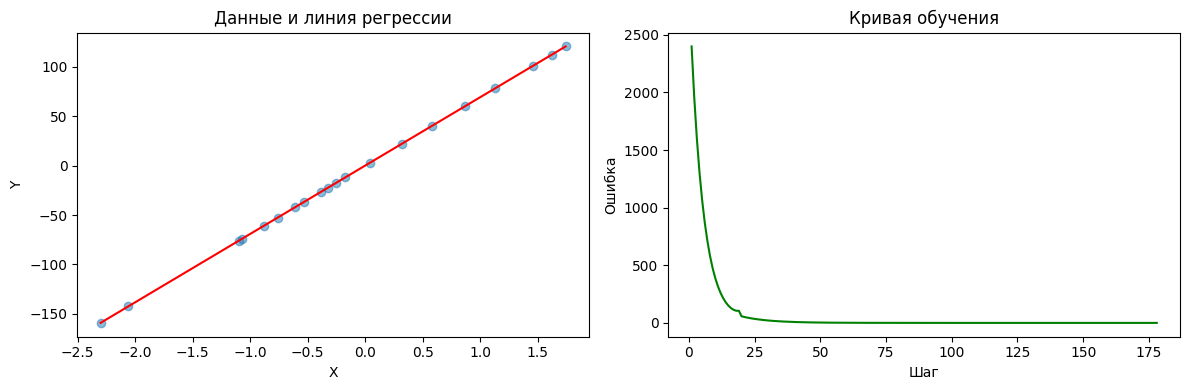

In [183]:
# Создаем и обучаем модель с нормированием
model_norm = Model()
steps, errors = model_norm.fit(x, y)

# Сравниваем с обычной моделью (из предыдущего задания)
model_plain = Model()
model_plain.ALPHA = 1.7
model_plain.b0 = -0.000074  # параметры из задания 6
model_plain.b1 = 69.187677

print("\n" + "="*50)
print("СРАВНЕНИЕ РЕЗУЛЬТАТОВ")
print("="*50)
print(f"{'Параметр':<15} {'С нормировкой':<20} {'Без нормировки':<20}")
print("-"*55)
print(f"{'b₀':<15} {model_norm.b0:<20.6f} {model_plain.b0:<20.6f}")
print(f"{'b₁':<15} {model_norm.b1:<20.6f} {model_plain.b1:<20.6f}")
print(f"{'Ошибка':<15} {model_norm.error(x, y):<20.6f} {model_plain.error(x, y):<20.6f}")

# График
model_norm.plot(x, y, steps, errors)